# Inflation Surprise

This model will look at trading energy futures based on their inflation surprise using Bloomberg Inflation Surprise Indices

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
energy_tickers = ["CL", "CO", "HO", "NG", "QS", "XB"]
inf_tickers    = ["BCMPGBIF", "BCMPUSIF"]

In [3]:
data_path = r"A:\BBGData\data"
inf_paths = [os.path.join(data_path, ticker + ".parquet") for ticker in inf_tickers]
df_inf    = (pd.read_parquet(
    path = inf_paths, engine = "pyarrow").
    assign(country = lambda x: np.where(x.security.str.split(" ").str[0] == "BCMPGBIF", "UK", "US")))

In [4]:
fut_path   = r"A:\BBGFuturesManager_backup_backup\data\PXFront"
fut_paths  = [os.path.join(fut_path, ticker + ".parquet") for ticker in energy_tickers]
df_fut_rtn = (pd.read_parquet(
    path = fut_paths, engine = "pyarrow").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

# Trading OLS

In [5]:
df_inf_prep = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    diff().
    reset_index().
    melt(id_vars = "date", value_name = "inf_surp").
    dropna())

In [6]:
df_combined = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 10, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "vol_rtn").
    dropna().
    merge(right = df_inf_prep, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.security + " " + x.country))

In [7]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_out = (sm.OLS(
        endog = df.vol_rtn,
        exog  = sm.add_constant(df.inf_surp)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_ols = (df_combined.set_index(
    "date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    merge(right = df_fut_rtn, how = "inner", on = ["date", "security"]))

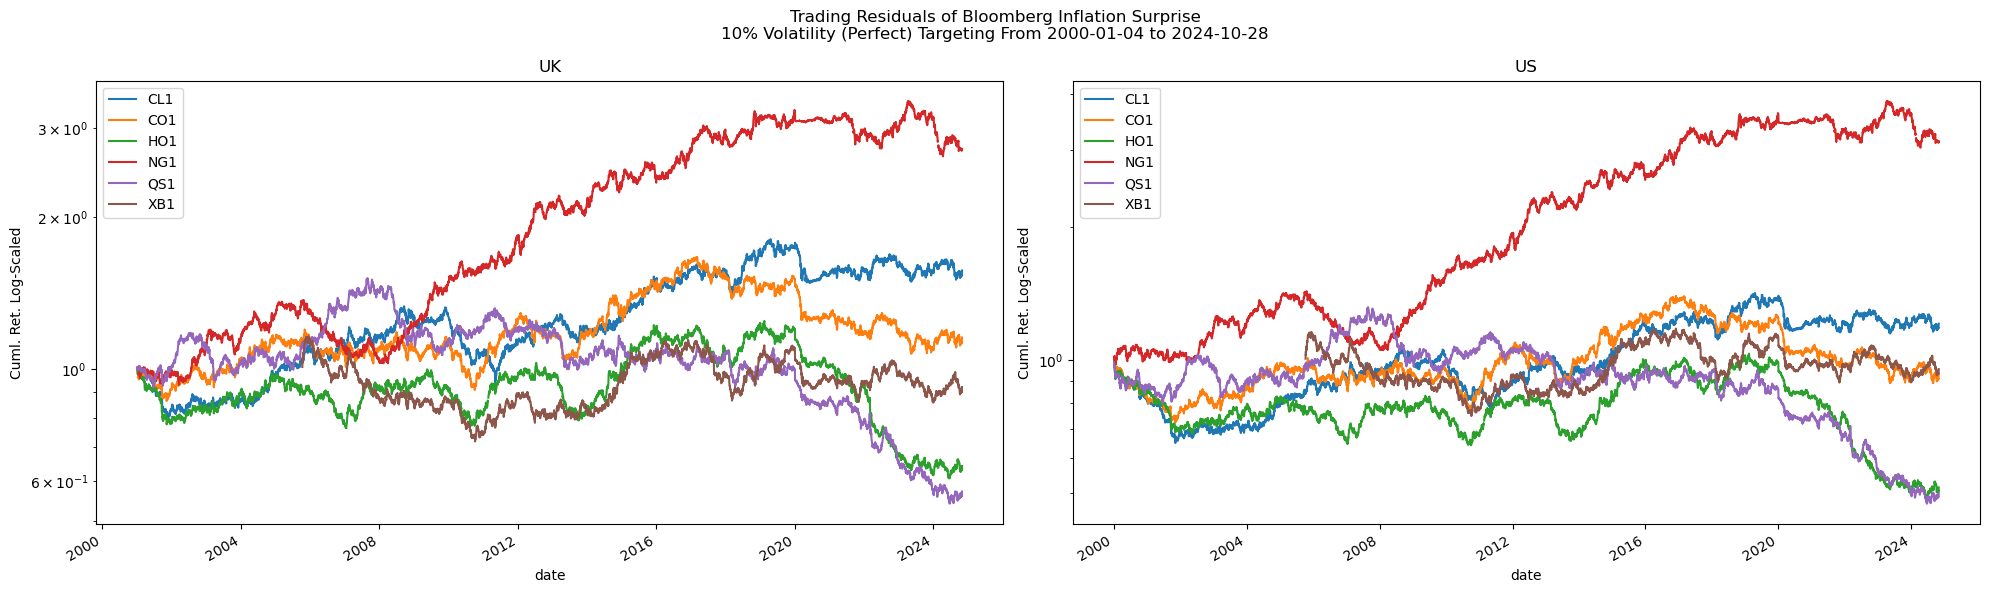

In [8]:
countrys  = df_ols.country.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(countrys), figsize = (20,6))

for country, ax in zip(countrys, axes.flatten()):

    (df_ols.assign(
        signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
        query("country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = country))

fig.suptitle("Trading Residuals of Bloomberg Inflation Surprise\n10% Volatility (Perfect) Targeting From {} to {}".format(
    df_ols.date.min().date(),
    df_ols.date.max().date()))
plt.tight_layout()

In [9]:
df_decile_sharpe = (df_ols[
    ["security", "decile", "country", "fut_rtn"]].
    groupby(["security", "decile", "country"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

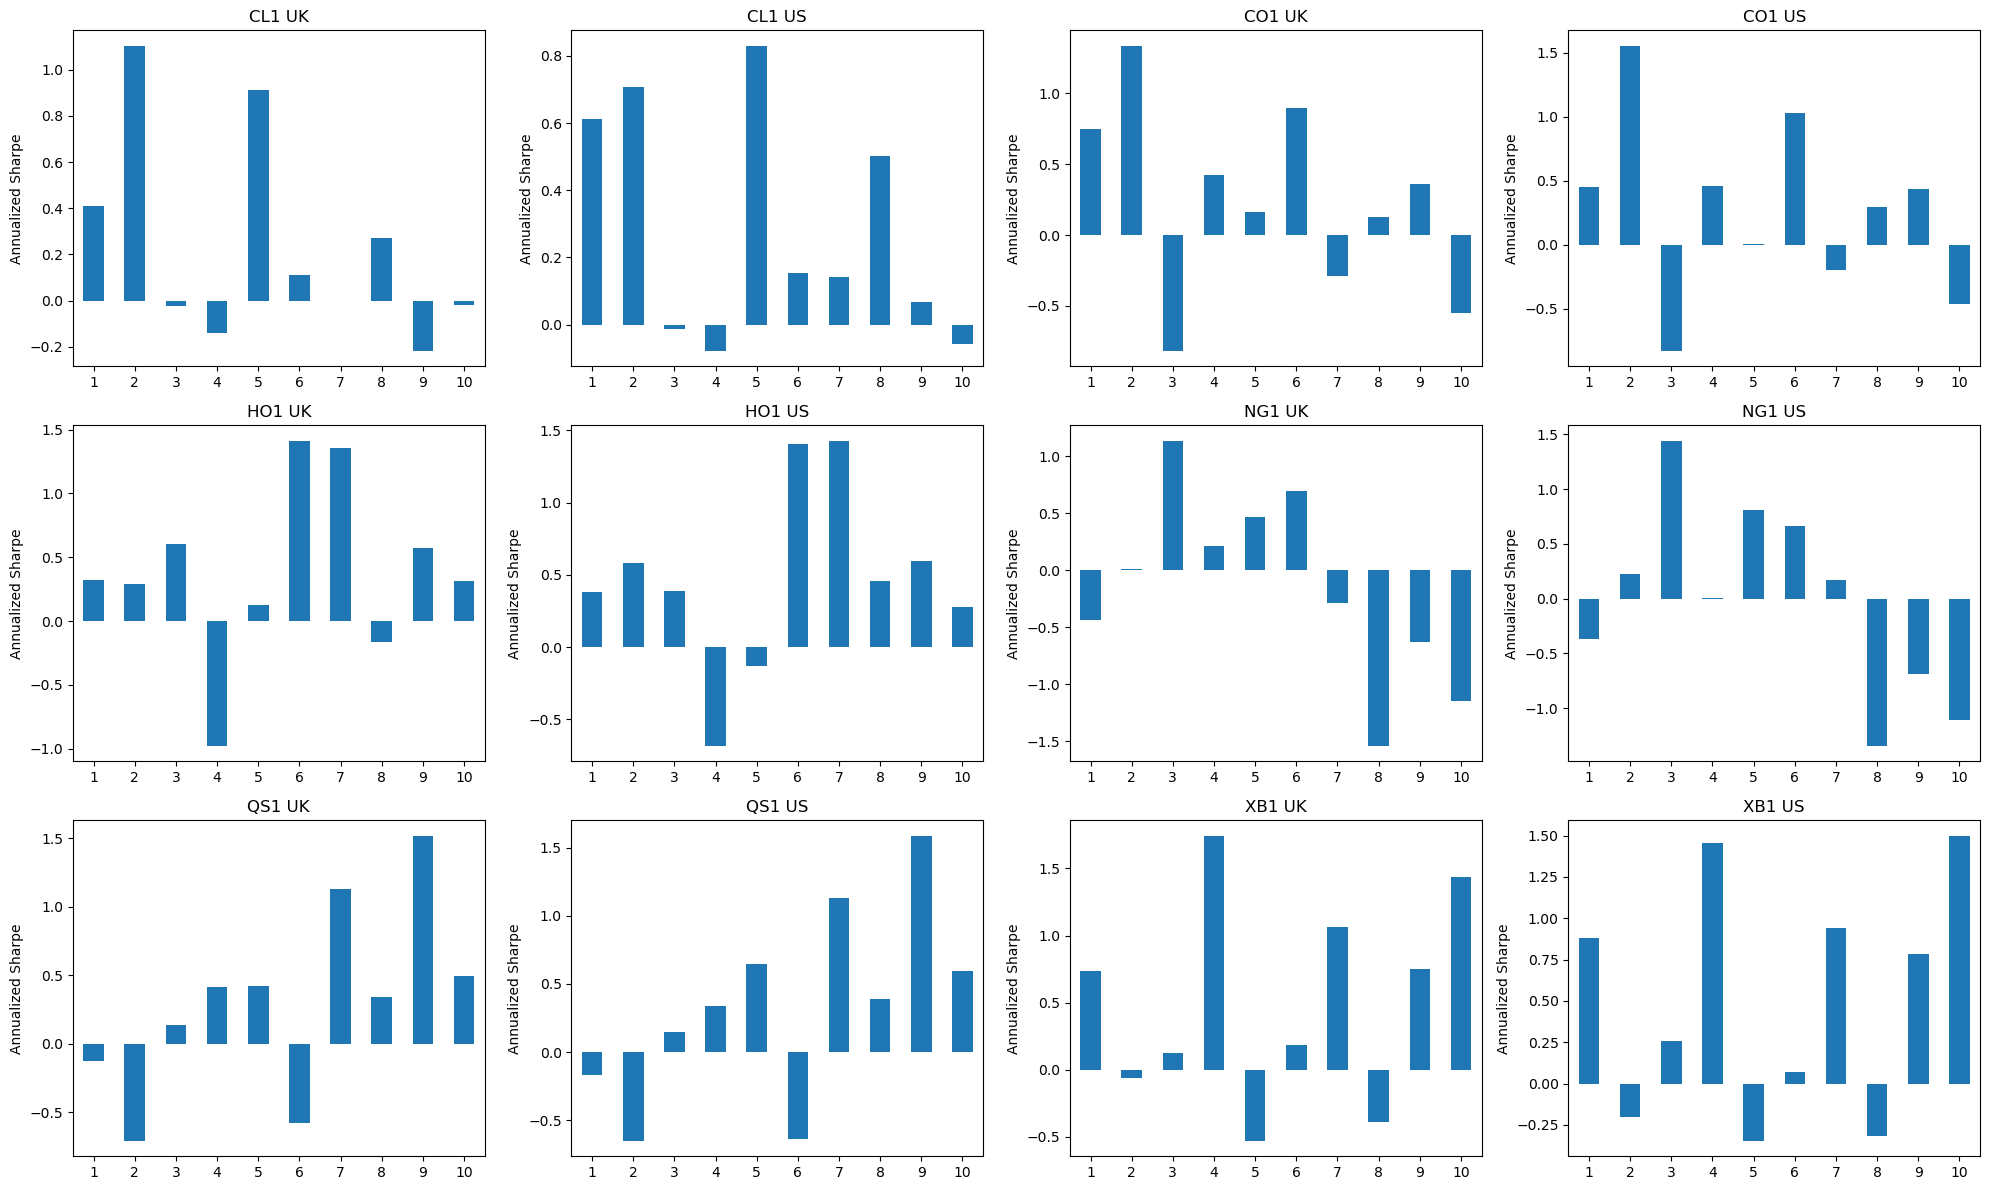

In [10]:
df_tmp = (df_decile_sharpe.assign(
    group_var = lambda x: x.security + " " + x.country))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 4, nrows = 3, figsize = (20,12))

for group_var, ax in zip(group_vars, axes.flatten()): 
    
    (df_tmp.query(
        "group_var == @group_var").
        set_index("decile")
        [["fut_rtn"]].
        plot(
            kind   = "bar",
            legend = False,
            xlabel = "",
            rot    = 0,
            ylabel = "Annualized Sharpe",
            title  = group_var,
            ax     = ax))
    
plt.tight_layout()

In [11]:
df_decile_group = (df_tmp.query(
    "decile == [1,2,9,10]").
    assign(a = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [12]:
df_signal_rtn = (df_decile_group[
    ["group_var", "a", "fut_rtn"]].
    groupby(["group_var", "a"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.fut_rtn > 0, 1, 0)).
    drop(columns = ["fut_rtn"]).
    merge(right = df_decile_group, how = "inner", on = ["group_var", "a"]).
    rename(columns = {"fut_rtn": "sharpe"}).
    merge(right = df_ols, how = "outer", on = ["group_var", "security", "decile", "country"]))

In [13]:
df_perf = (df_signal_rtn.assign(
    signal_rtn = lambda x: np.sign(x.sharpe * x.scaler) * x.fut_rtn).
    pivot(index = "date", columns = ["country", "security"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "signal_rtn").
    assign(group = "perf"))

df_lagged = (df_signal_rtn.assign(
    signal_rtn = lambda x: np.sign(x.sharpe * x.scaler) * x.fut_rtn).
    pivot(index = "date", columns = ["country", "security"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "signal_rtn").
    assign(group = "lagged"))

df_combined = (pd.concat([
    df_perf, df_lagged]).
    dropna().
    rename(columns = {("date", ""): "date"}))

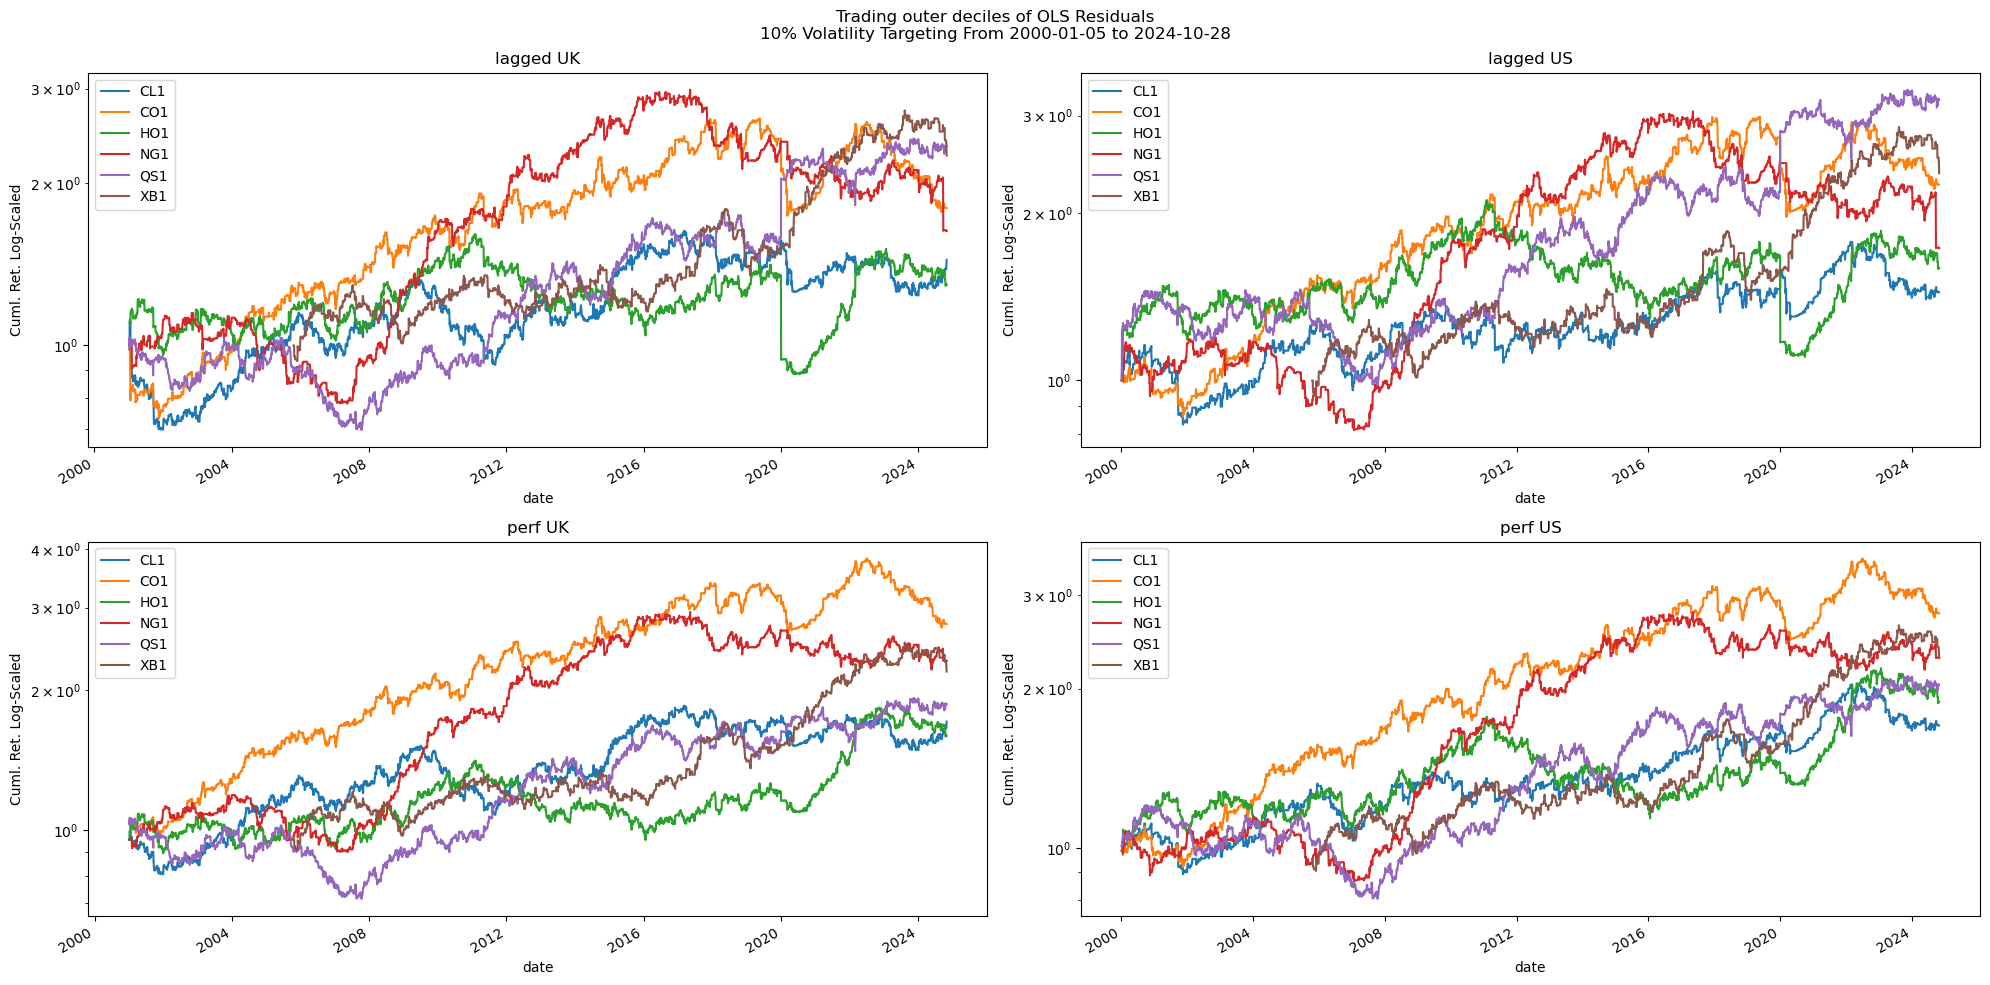

In [14]:
df_plot = (df_combined.assign(
    group_var = lambda x: x.group + " " + x.country))

group_vars = df_plot.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_plot.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var))

fig.suptitle("Trading outer deciles of OLS Residuals\n10% Volatility Targeting From {} to {}".format(
    df_plot.date.min().date(),
    df_plot.date.max().date()))
plt.tight_layout()

In [15]:
(df_combined.assign(
    adj_rtn = lambda x: np.where(x.signal_rtn != 0, x.signal_rtn, np.nan)).
    melt(id_vars = ["date", "country", "security", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["country", "security", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol Target",
        "variable": ""}).
    replace({
        "lagged"    : "Lagged",
        "perf"      : "Perfect",
        "adj_rtn"   : "Adj Sharpe",
        "signal_rtn": "Raw Sharpe"}).
    pivot(index = ["country", "security"], columns = ["Vol Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol Target           Lagged               Perfect           
                 Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
country security                                            
UK      CL1           0.306      0.188      0.448      0.275
        CO1           0.591      0.263      1.106      0.492
        HO1           0.247      0.152      0.402      0.248
        NG1           0.526      0.229      0.950      0.413
        QS1           0.561      0.351      0.500      0.312
        XB1           0.993      0.432      1.091      0.475
US      CL1           0.424      0.185      0.625      0.272
        CO1           0.772      0.343      1.079      0.479
        HO1           0.349      0.215      0.505      0.311
        NG1           0.556      0.242      0.910      0.396
        QS1           0.679      0.424      0.543      0.340
        XB1           1.043      0.453      1.146      0.498

Text(0.5, 0.98, 'Correlation of trading outer deciles of OLS Residuals\n10% Volatility Targeting From 2000-01-05 to 2024-10-28')

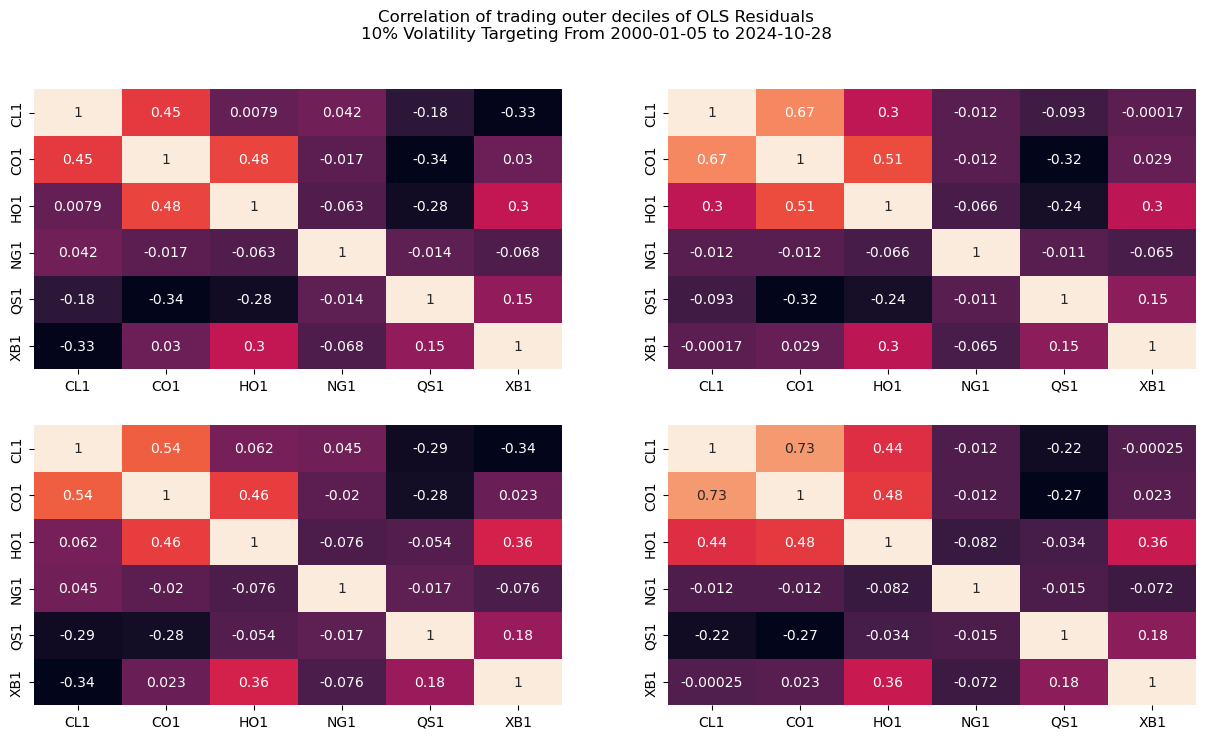

In [16]:
df_plot = (df_combined.assign(
    group_var = lambda x: x.group + " " + x.country))

group_vars = df_plot.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (15,8))

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_tmp = (df_plot.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        corr())

    sns.heatmap(
        data = df_tmp,
        ax   = ax,
        annot = True,
        cbar  = False)

fig.suptitle("Correlation of trading outer deciles of OLS Residuals\n10% Volatility Targeting From {} to {}".format(
    df_plot.date.min().date(),
    df_plot.date.max().date()))

In [17]:
df_avg_corr = (df_combined.pivot(
    index = ["date", "group", "country"], columns = "security", values = "signal_rtn").
    reset_index().
    drop(columns = ["date"]).
    groupby(["group", "country"]).
    agg("corr").
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["group", "country", "security1"]).
    query("security1 != security").
    drop(columns = ["security1", "security"]).
    groupby(["group", "country"]).
    agg("mean").
    reset_index())

In [18]:
df_tmp_lag = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date").
    assign(group = "lagged"))

df_tmp_perf = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date").
    assign(group = "perf"))

df_und = (pd.concat([
    df_tmp_lag, df_tmp_perf]).
    dropna().
    pivot(index = ["date", "group"], columns = "security", values = "value").
    reset_index().
    drop(columns = ["date"]).
    groupby("group").
    apply(lambda x: x.corr()).
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["group", "security1"]).
    query("security1 != security").
    drop(columns = ["security1", "security"]).
    groupby(["group"]).
    agg("mean").
    reset_index().
    assign(country = "und"))

In [19]:
(pd.concat([
    df_avg_corr, df_und]).
    replace({
        "lagged": "Lagged",
        "perf"  : "Perfect"}).
    pivot(index = "group", columns = "country", values = "value").
    apply(lambda x: np.round(x,3)).
    rename(columns = {"und": "Average"}))

country,UK,US,Average
group,,,
Lagged,0.010,0.076,0.482
Perfect,0.035,0.100,0.572


In [20]:
df_avg = (df_combined.drop(
    columns = ["security"]).
    groupby(["date", "country", "group"]).
    agg("mean").
    reset_index())

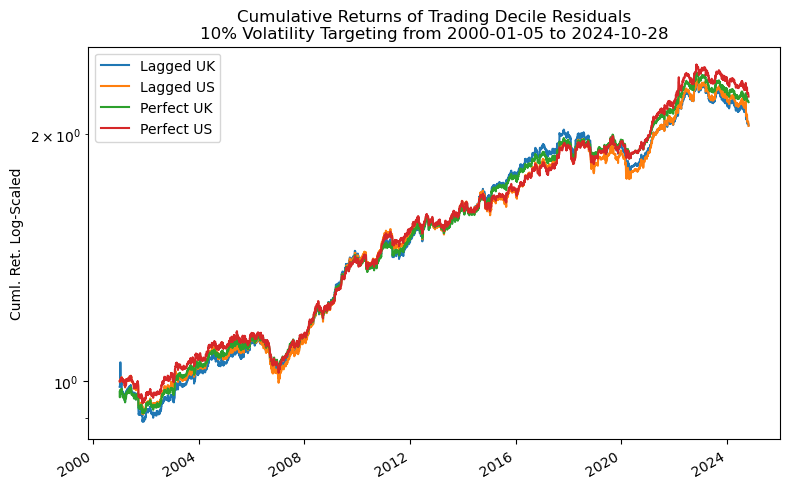

In [21]:
(df_avg.assign(
    group = lambda x: np.where(x.group == "lagged", "Lagged", "Perfect"),
    tmp   = lambda x: x.group + " " + x.country).
    rename(columns = {"tmp": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    dropna().
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        xlabel  = "",
        title   = "Cumulative Returns of Trading Decile Residuals\n10% Volatility Targeting from {} to {}".format(
            df_avg.date.min().date(),
            df_avg.date.max().date())))

plt.tight_layout()

In [22]:
(df_avg.assign(
    adj_rtn = lambda x: np.where(x.signal_rtn != 0, x.signal_rtn, np.nan)).
    melt(id_vars = ["date", "country", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["country", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol Target",
        "variable": ""}).
    replace({
        "adj_rtn"   : "Adj. Sharpe",
        "signal_rtn": "Raw. Sharpe",
        "lagged"    : "Lagged",
        "perf"      : "Perfect"}).
    pivot(index = "country", columns = ["Vol Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol Target      Lagged                 Perfect            
           Adj. Sharpe Raw. Sharpe Adj. Sharpe Raw. Sharpe
country                                                   
UK               0.704       0.594       0.936       0.790
US               0.773       0.643       0.896       0.746